In [1]:
import sys
sys.path.append(".")
from collections import defaultdict

import pyarrow.feather as feather
import numpy as np
import itertools
from pathlib import Path
from utils import *
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import networkx as nx

import matplotlib.cm as cm
import matplotlib.colors as mcolors

from tqdm.auto import tqdm

import seaborn as sns
sns.set_context("notebook", font_scale=1.2)
colors = sns.color_palette("muted")

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

In [2]:
sweep_string = "sweep_2026_06_22_2150/"
DATA_DIR = Path("data/" + sweep_string)
sim_df = feather.read_feather(DATA_DIR / "simulations.arrow")
node_df = feather.read_feather(DATA_DIR / "nodes.arrow")
edge_df = feather.read_feather(DATA_DIR / "edges.arrow")
print("Simulations:", sim_df.shape)
print("Nodes:", node_df.shape)

Simulations: (50000, 13)
Nodes: (15000000, 15)


### Compute Agent Veracity

In [3]:
def compute_normalized_payoff(row):
    rep = row["payoff"]
    best = row["best_payoff"]
    worst = row["worst_payoff"]
    
    if rep < 0 and worst != 0:
        return - (rep / worst)
    elif rep > 0 and best != 0:
        return rep / best
    else:
        return 0.0

node_df["agent_veracity"] = node_df.apply(compute_normalized_payoff, axis=1)

In [4]:
# proportion of all agents who never had any option to do anything
print(round(len(node_df[(node_df["best_payoff"]==0)&(node_df["worst_payoff"]==0)]) / len(node_df), 3))

0.008


In [5]:
# proportion of all agents with zero final payoff
print(round(len(node_df[(node_df["payoff"]==0)]) / len(node_df), 3))

0.283


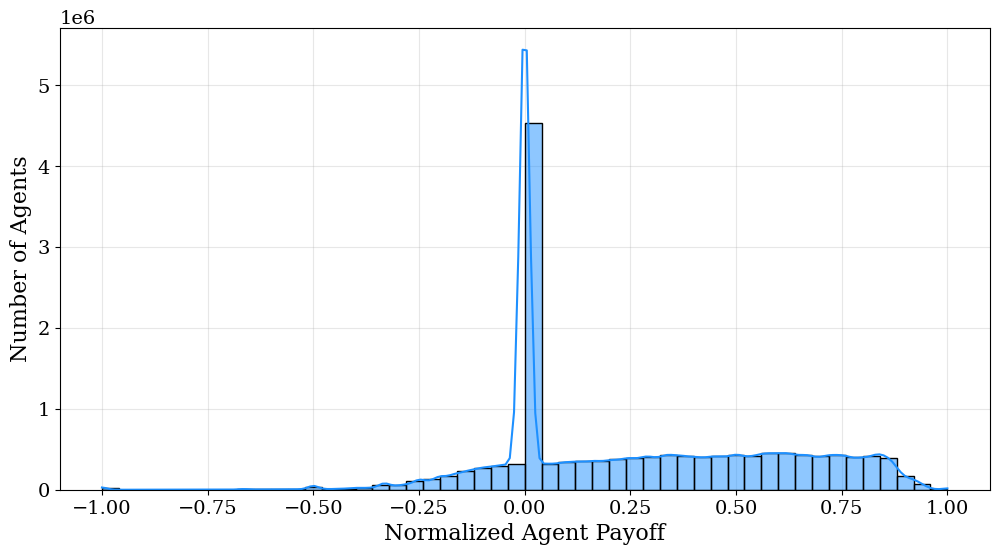

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(node_df['agent_veracity'], bins=50, kde=True, color='dodgerblue')
plt.xlabel("Normalized Agent Payoff")
plt.ylabel("Number of Agents")
plt.grid()
plt.show()

### Compute Sen Welfare For Each Simulation

In [7]:
# compute sen welfare per simulation
sen_values = (
    node_df
    .groupby("global_sim_id")["agent_veracity"]
    .apply(lambda x: sen_welfare(x.values))
    .reset_index()
    .rename(columns={"agent_veracity": "sen_welfare"})
)

sim_df = sim_df.merge(sen_values, on="global_sim_id")

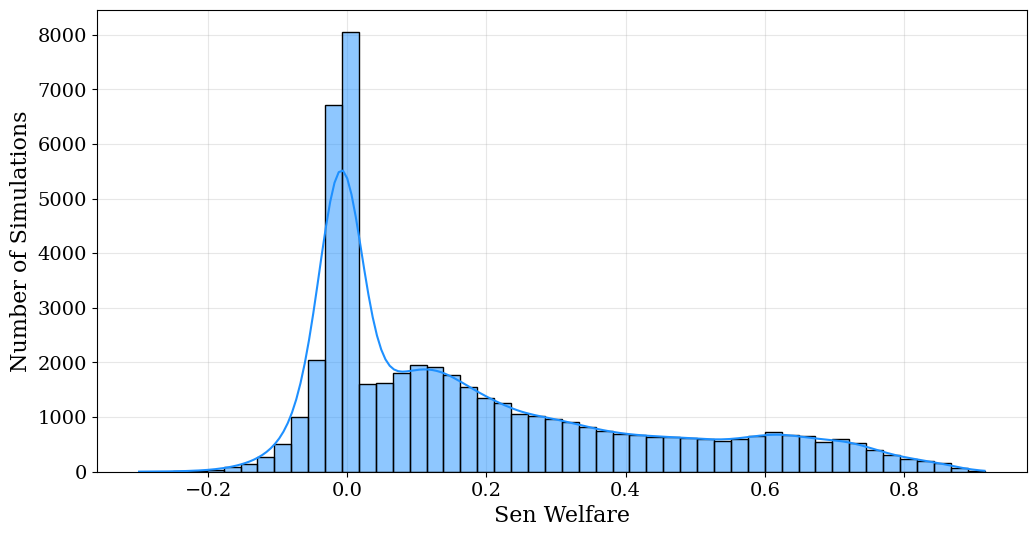

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(sim_df['sen_welfare'], bins=50, kde=True, color='dodgerblue')
plt.xlabel("Sen Welfare")
plt.ylabel("Number of Simulations")
plt.grid()
plt.show()

### Heatmaps for veracity differential and sen welfare over parameter space

In [9]:
# bin resolution
N_BINS = 10

param_cols = [
    "v_cost",
    "loss",
    "tpr",
    "fpr",
    "p_fake"
]

param_pairs = list(itertools.combinations(param_cols, 2))
len(param_pairs)

10

In [10]:
def plot_hexbin_grid(df, value_col, title, bins=N_BINS):
    fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
    axes = axes.flatten()

    for ax, (xparam, yparam) in zip(axes, param_pairs):
        hb = ax.hexbin(
            df[xparam],
            df[yparam],
            C=df[value_col],
            reduce_C_function=np.mean,
            gridsize=bins,
            cmap="viridis"
        )
        ax.set_xlabel(xparam)
        ax.set_ylabel(yparam)
        ax.set_title(f"{xparam} vs {yparam}")

    fig.suptitle(title, fontsize=18)
    fig.tight_layout()
    cbar = fig.colorbar(hb, ax=axes.tolist())
    cbar.set_label(value_col)
    plt.show()

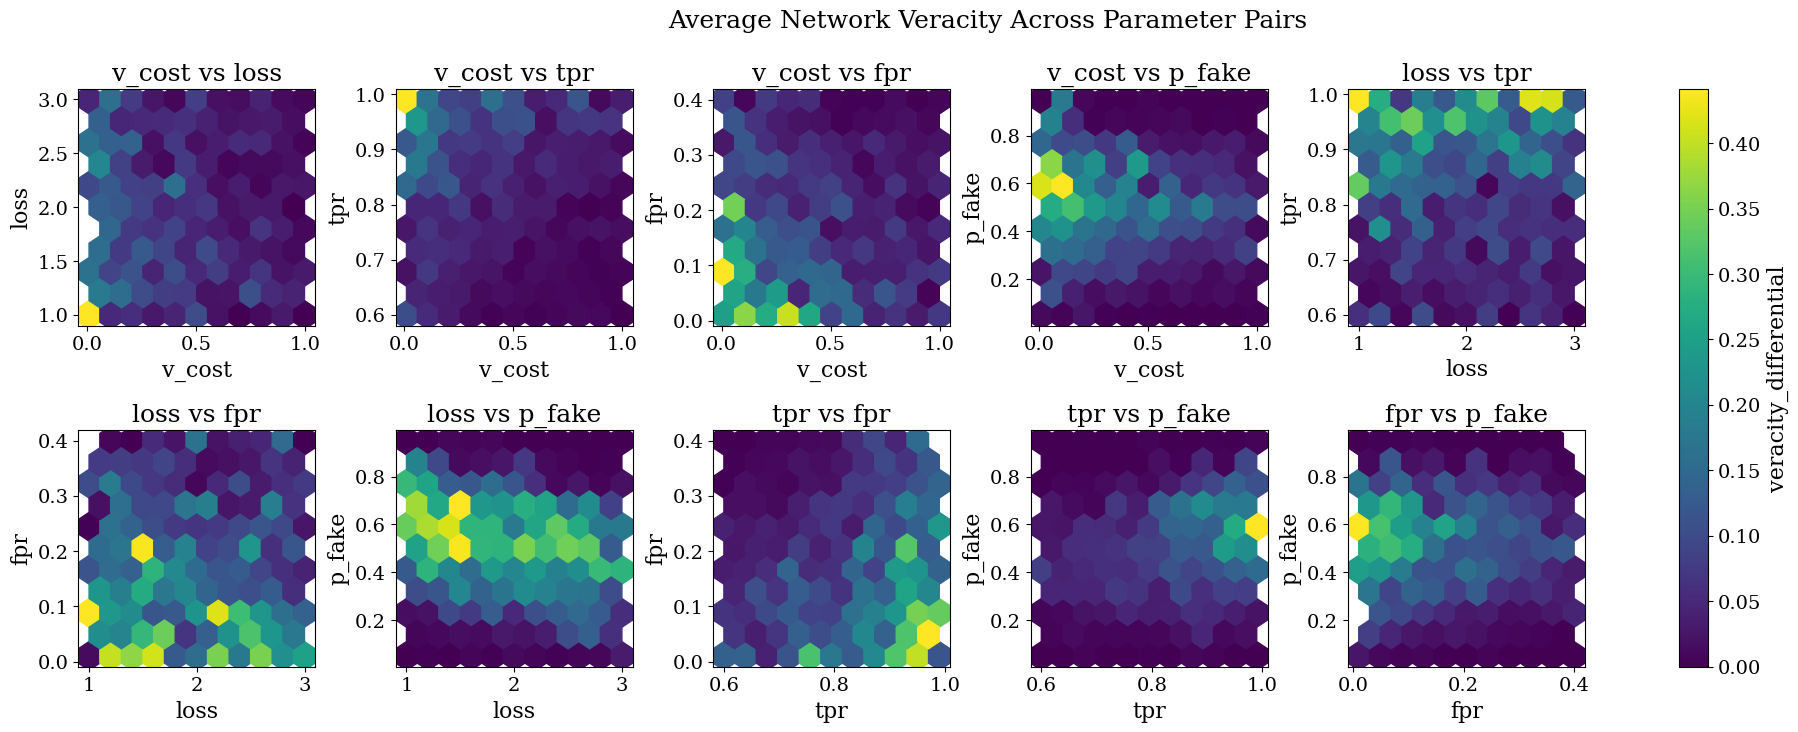

In [11]:
plot_hexbin_grid(
    sim_df,
    value_col="veracity_differential",
    title="Average Network Veracity Across Parameter Pairs"
)

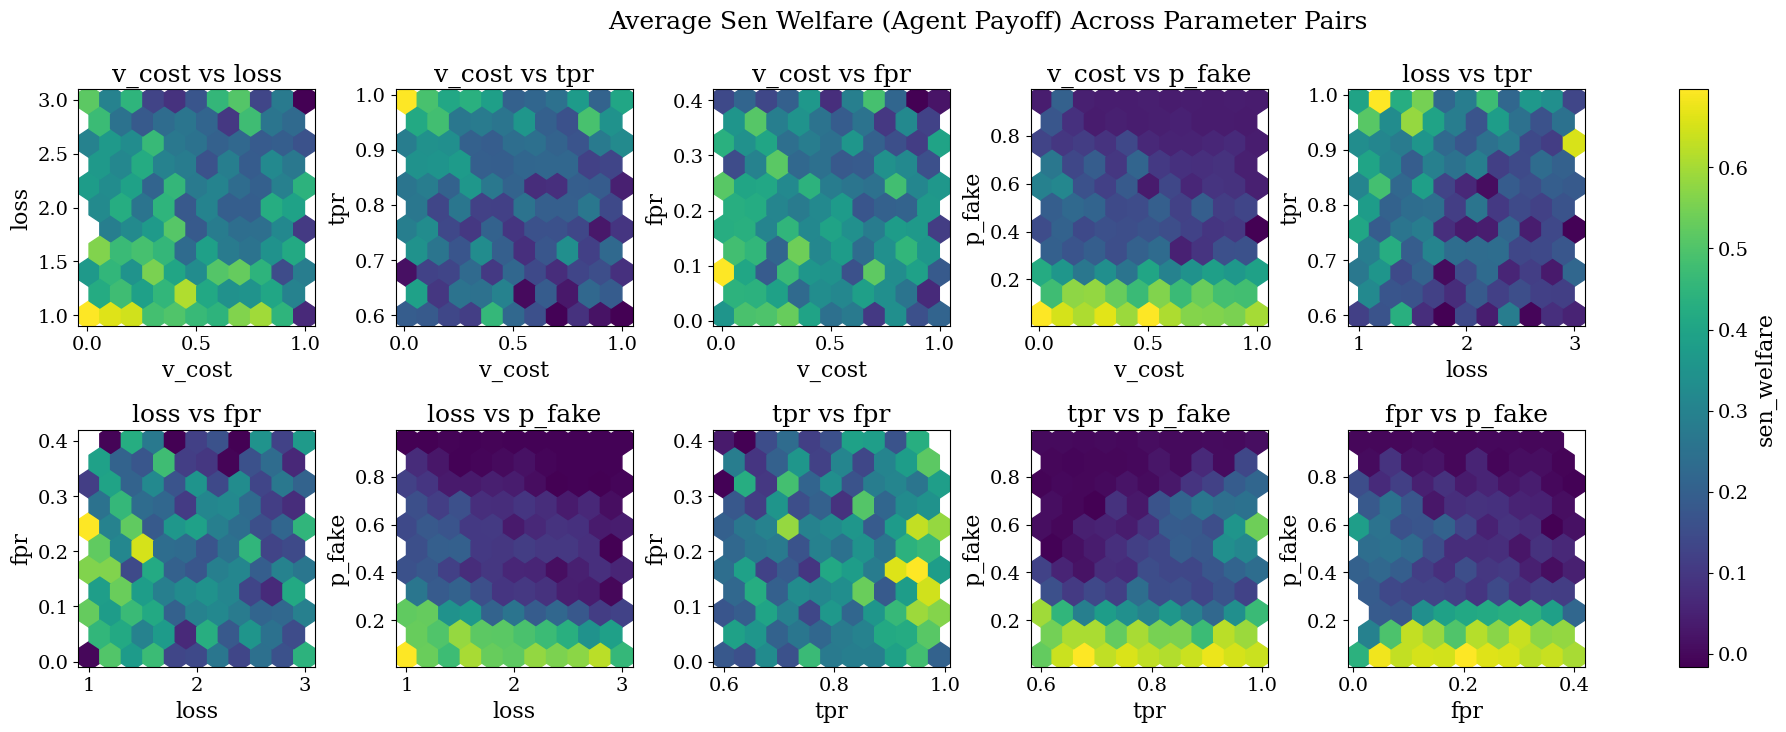

In [12]:
plot_hexbin_grid(
    sim_df,
    value_col="sen_welfare",
    title="Average Sen Welfare (Agent Payoff) Across Parameter Pairs"
)

### Average Average Verification Rate Versus Veracity Differential

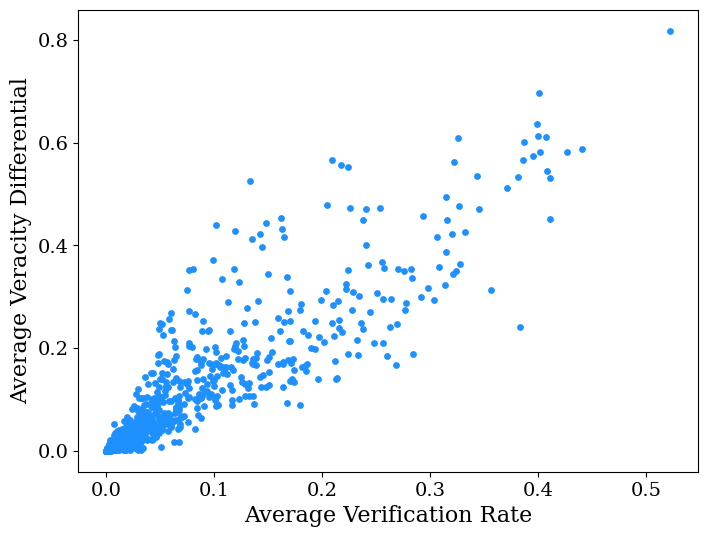

In [13]:
plt.scatter(
    sim_df.groupby("lhs_id")["avg_verify_rate"].mean(),
    sim_df.groupby("lhs_id")["veracity_differential"].mean(),
    color="dodgerblue",
    s=15
)

plt.xlabel("Average Verification Rate")
plt.ylabel("Average Veracity Differential")
plt.show()

### True and Fake Cascade Sizes

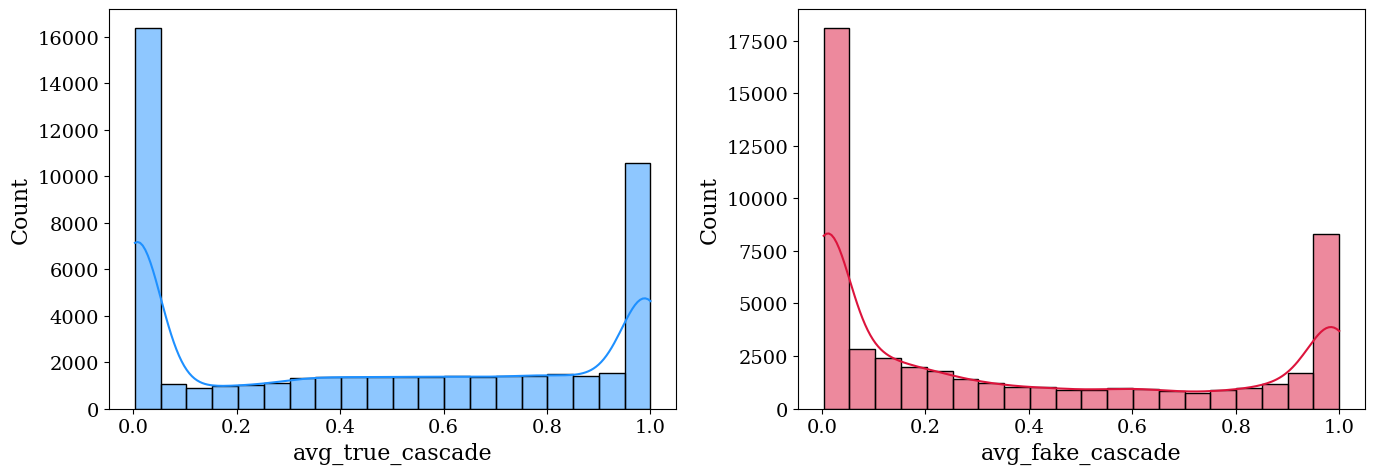

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(sim_df["avg_true_cascade"], bins=20, kde=True, color="dodgerblue", ax=axes[0])
sns.histplot(sim_df["avg_fake_cascade"], bins=20, kde=True, color="crimson", ax=axes[1])

fig.tight_layout()
plt.show()

### Agent belief of global truth prevalence vs. actual

In [15]:
# Calculate true prevalence for all rows
node_df = node_df.copy()
node_df['true_prevalence'] = node_df['true_alpha'] / (node_df['true_alpha'] + node_df['true_beta'])

# Merge node_df with sim_df to get p_true in one shot
merged = node_df.merge(
    sim_df[['global_sim_id', 'p_fake']],
    on='global_sim_id',
    how='left'
)

# Compute p_true
merged['p_true'] = 1 - merged['p_fake']

# Group by p_true and sum true_prevalence
data = merged.groupby('p_true')['true_prevalence'].mean().to_dict()

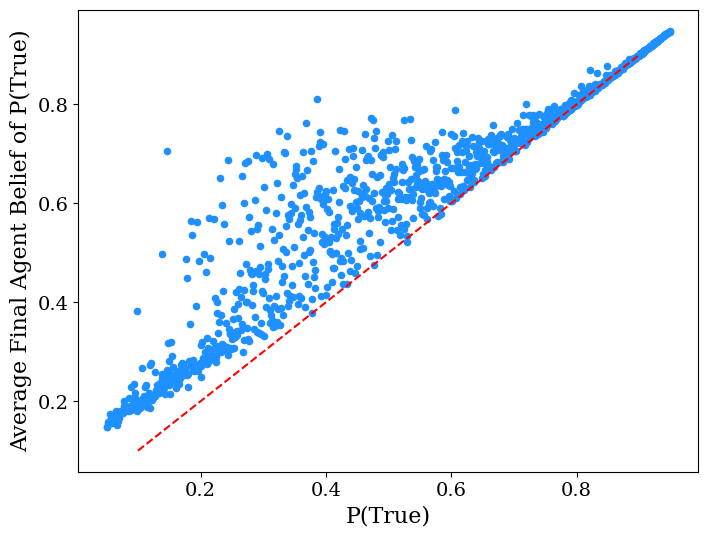

In [16]:
plt.scatter(
    list(data.keys()),
    list(data.values()),
    color="dodgerblue",
    s=20
)
plt.xlabel("P(True)")
plt.ylabel("Average Final Agent Belief of P(True)")

plt.plot(
    np.linspace(0.1, 0.9, 2),
    np.linspace(0.1, 0.9, 2),
    color="red",
    linestyle="dashed"
)

plt.show()

### Discard Rate

In [17]:
# recorded cascades per sim = cascades_per_sim - burn_in (2000 - 1000 for the full sweep)
N_RECORDED_CASCADES = 1000
discard_rate = []
for _, group in node_df.groupby("global_sim_id"):
    D = (N_RECORDED_CASCADES - group["true_shares"] - group["fake_shares"]) / N_RECORDED_CASCADES
    discard_rate.append(np.mean(D))

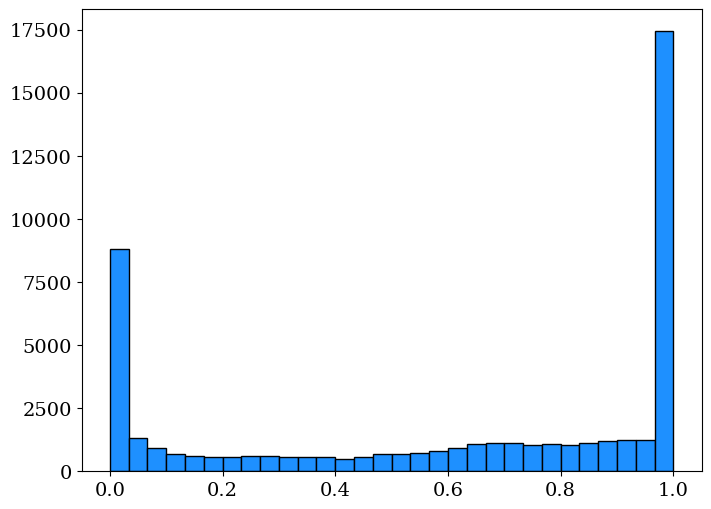

In [18]:
plt.hist(discard_rate, color="dodgerblue", edgecolor="k", bins=30)
plt.show()

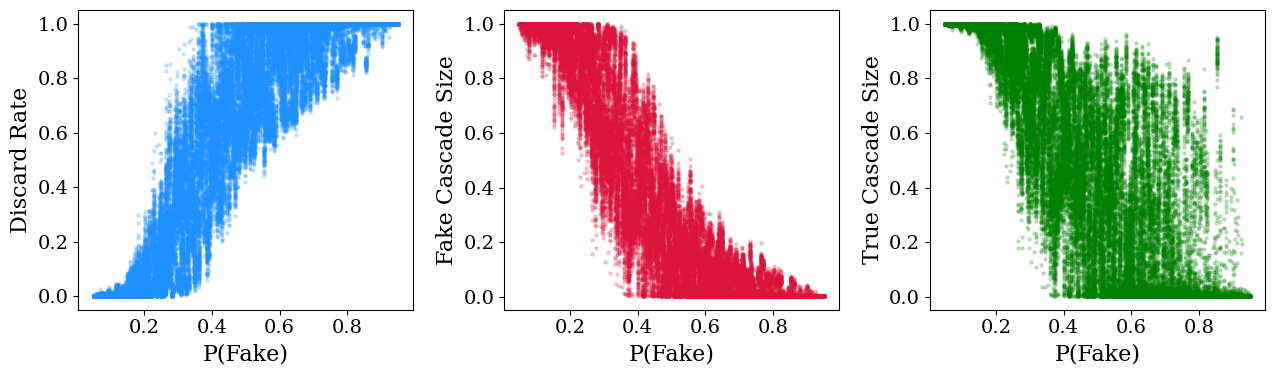

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(13,4))

axs[0].scatter(
    sim_df["p_fake"],
    discard_rate,
    s=5,
    color="dodgerblue",
    alpha=0.2
)
axs[0].set_ylabel("Discard Rate")

axs[1].scatter(
    sim_df["p_fake"],
    sim_df["avg_fake_cascade"].values,
    s=5,
    color="crimson",
    alpha=0.2
)
axs[1].set_ylabel("Fake Cascade Size")

axs[2].scatter(
    sim_df["p_fake"],
    sim_df["avg_true_cascade"].values,
    s=5,
    color="green",
    alpha=0.2
)
axs[2].set_ylabel("True Cascade Size")

for i in range(3):
    axs[i].set_xlabel("P(Fake)")

fig.tight_layout()
plt.show()

### Belief Polarization

In [20]:
psi = []
bc = []
for id, g in tqdm(node_df.groupby("global_sim_id")):
    tpr_mean = g["tpr_alpha"] / (g["tpr_alpha"] + g["tpr_beta"])
    psi.append(polarization(tpr_mean))
    bc.append(bimodality_coefficient(tpr_mean))

  0%|          | 0/50000 [00:00<?, ?it/s]

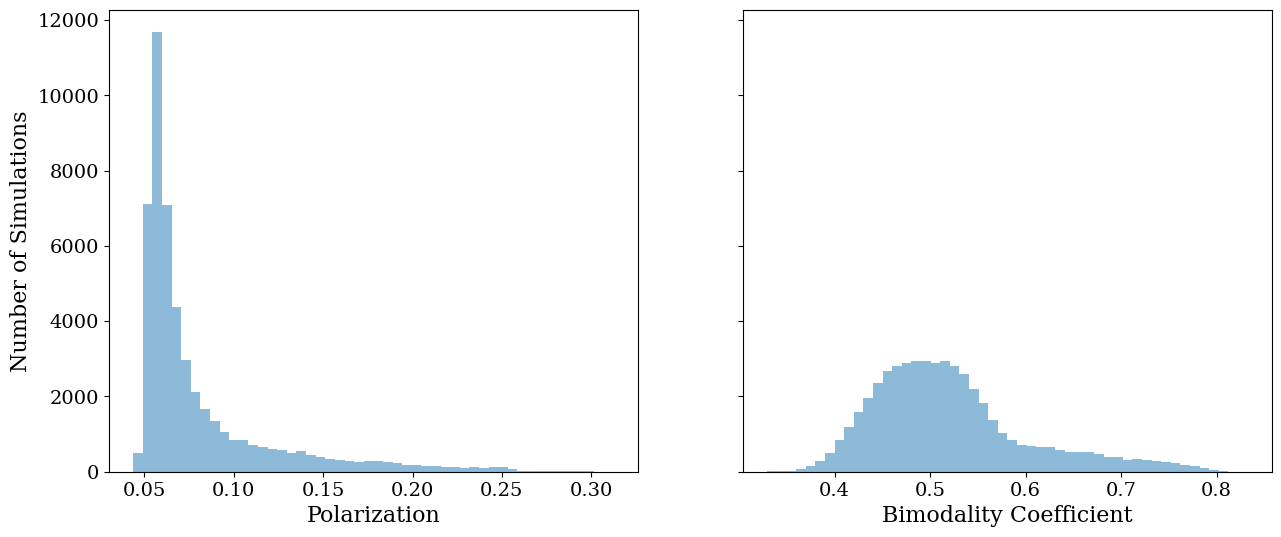

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(15,6), sharey=True)

axs[0].hist(psi, bins=50, alpha=0.5)
axs[0].set_xlabel("Polarization")
axs[0].set_ylabel("Number of Simulations")

axs[1].hist(bc, bins=50, alpha=0.5)
axs[1].set_xlabel("Bimodality Coefficient")

plt.show()

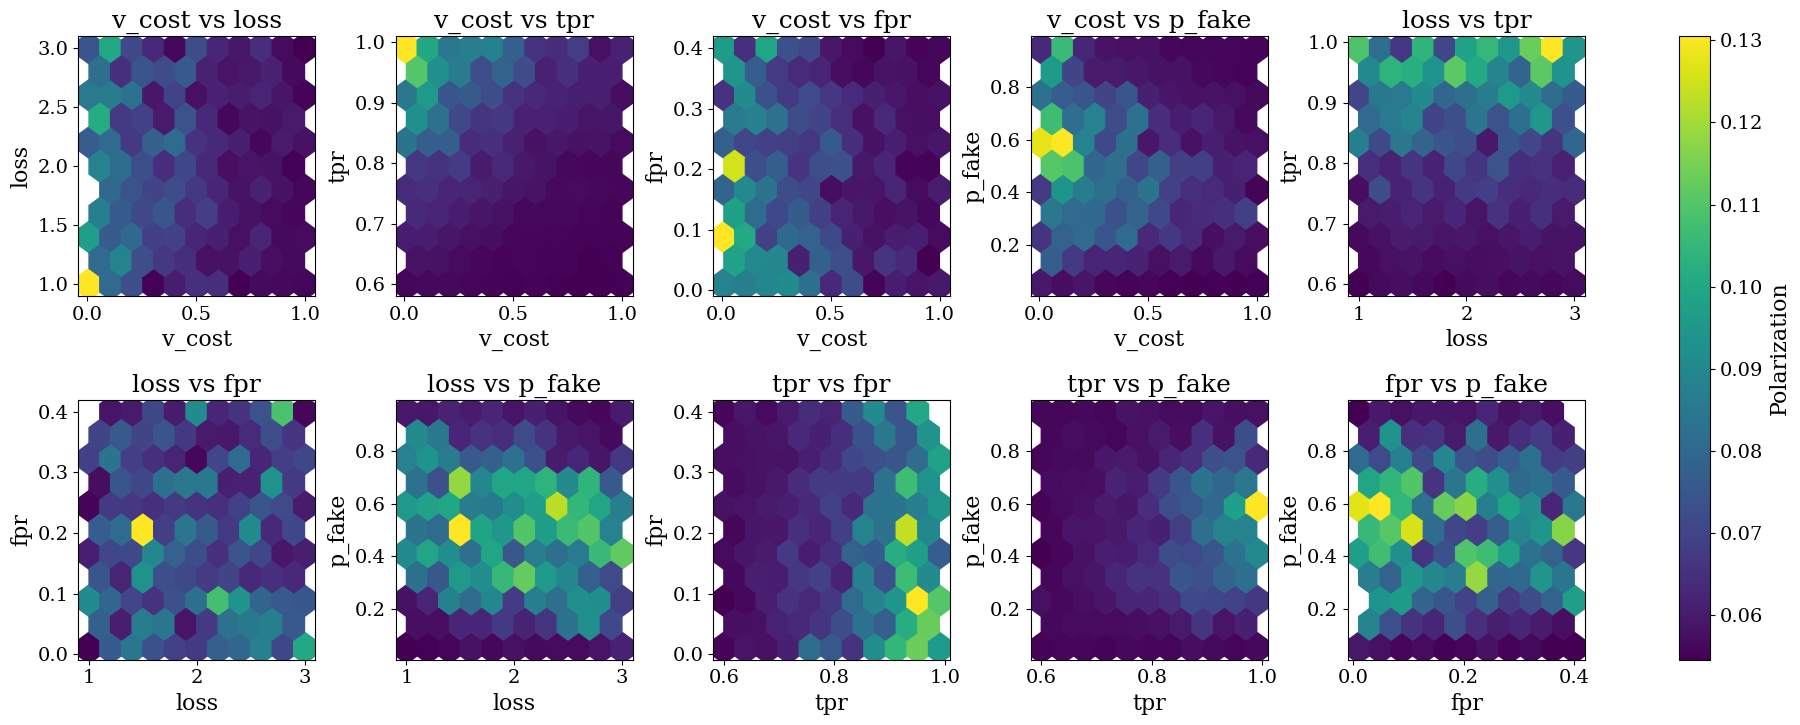

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
axes = axes.flatten()

for ax, (xparam, yparam) in zip(axes, param_pairs):
    hb = ax.hexbin(
        sim_df[xparam],
        sim_df[yparam],
        C=psi,
        reduce_C_function=np.mean,
        gridsize=10,
        cmap="viridis"
    )
    ax.set_xlabel(xparam)
    ax.set_ylabel(yparam)
    ax.set_title(f"{xparam} vs {yparam}")

fig.tight_layout()
cbar = fig.colorbar(hb, ax=axes.tolist())
cbar.set_label("Polarization")
plt.show()

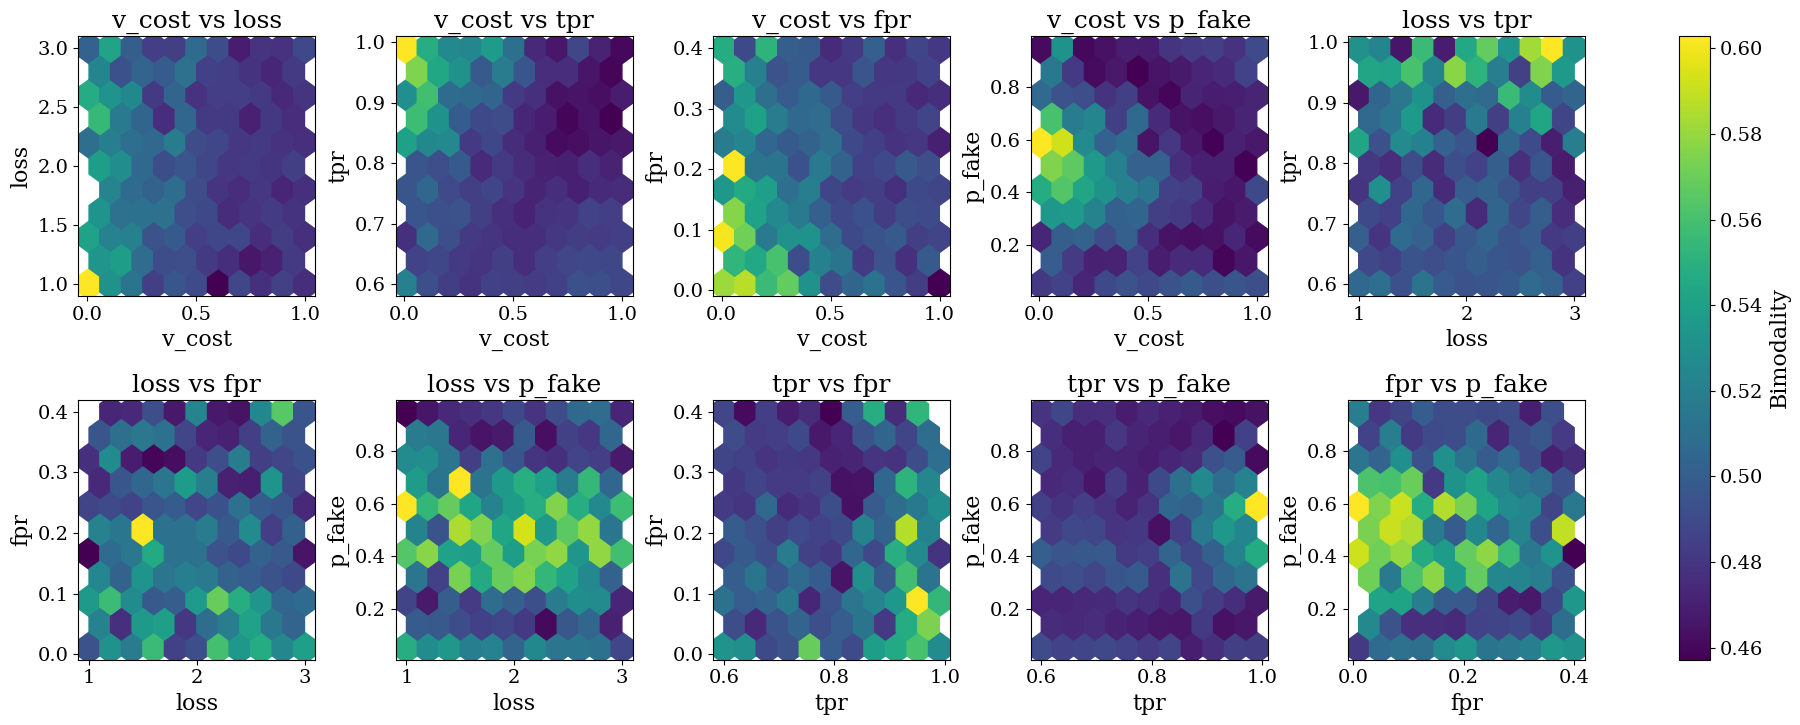

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
axes = axes.flatten()

for ax, (xparam, yparam) in zip(axes, param_pairs):
    hb = ax.hexbin(
        sim_df[xparam],
        sim_df[yparam],
        C=bc,
        reduce_C_function=np.mean,
        gridsize=10,
        cmap="viridis"
    )
    ax.set_xlabel(xparam)
    ax.set_ylabel(yparam)
    ax.set_title(f"{xparam} vs {yparam}")

fig.tight_layout()
cbar = fig.colorbar(hb, ax=axes.tolist())
cbar.set_label("Bimodality")
plt.show()

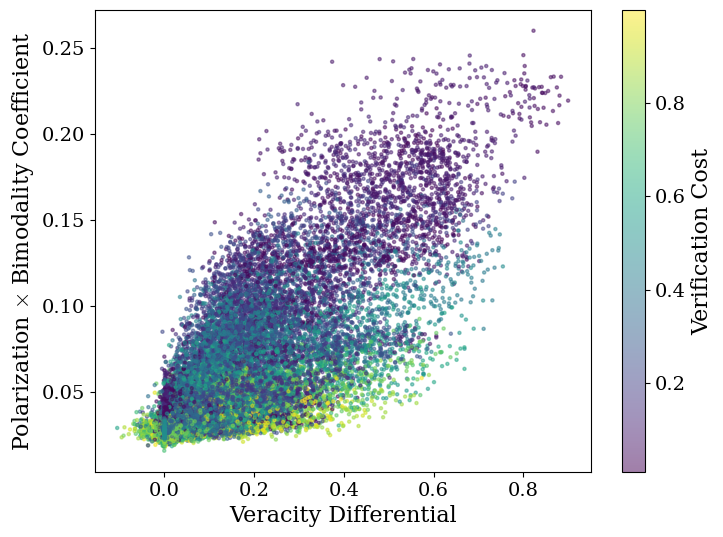

In [24]:
plt.scatter(
    sim_df["veracity_differential"],
    np.array(bc)*np.array(psi),
    s=5,
    c=sim_df["v_cost"],
    alpha=0.5
)
plt.xlabel("Veracity Differential")
plt.ylabel(r"Polarization $\times$ Bimodality Coefficient")
plt.colorbar(label="Verification Cost")
plt.show()

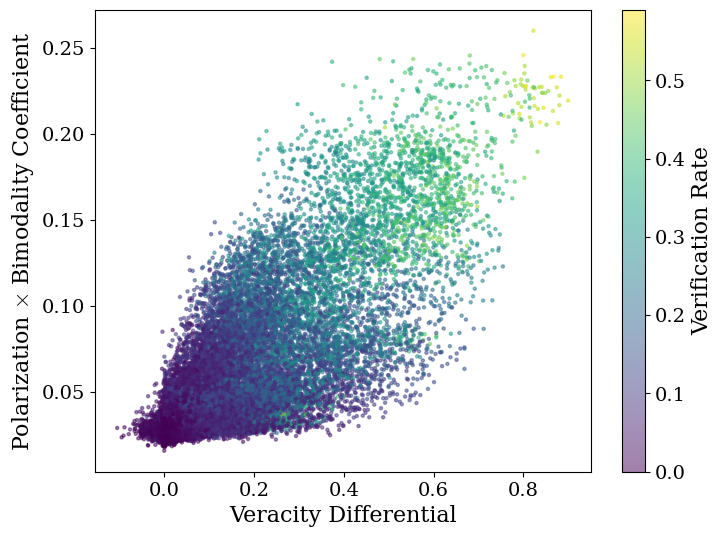

In [25]:
plt.scatter(
    sim_df["veracity_differential"],
    np.array(bc)*np.array(psi),
    s=5,
    c=sim_df["avg_verify_rate"],
    alpha=0.5
)
plt.xlabel("Veracity Differential")
plt.ylabel(r"Polarization $\times$ Bimodality Coefficient")
plt.colorbar(label="Verification Rate")
plt.show()

### Regimes

In [26]:
vd = sim_df["veracity_differential"].values
sw = sim_df["sen_welfare"].values

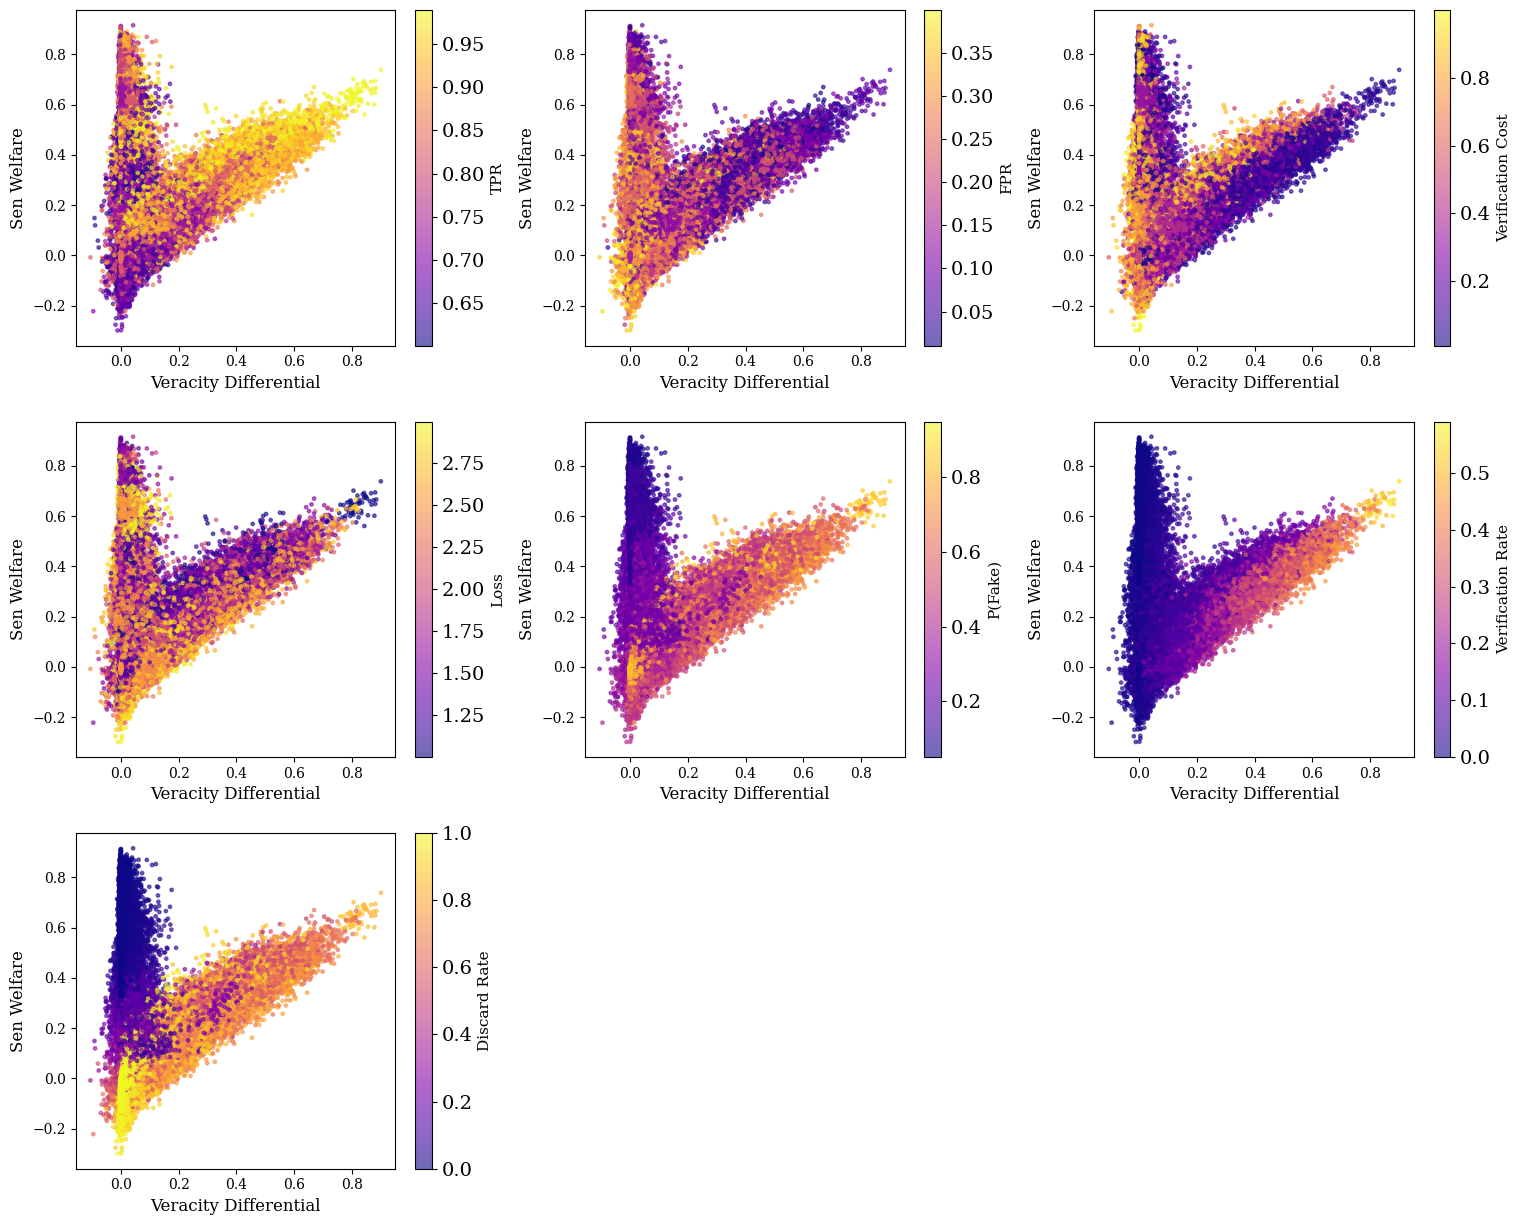

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15.5, 12.5))

# Flatten axes for easy iteration
axes = axes.flatten()

# List of (data, label) pairs
color_vars = [
    (sim_df["tpr"].values, "TPR"),
    (sim_df["fpr"].values, "FPR"),
    (sim_df["v_cost"].values, "Verification Cost"),
    (sim_df["loss"].values, "Loss"),
    (sim_df["p_fake"].values, "P(Fake)"),
    (sim_df["avg_verify_rate"].values, "Verification Rate"),
    (discard_rate, "Discard Rate"),
]

# Loop through variables and plot
for i, (cvals, label) in enumerate(color_vars):
    ax = axes[i]
    sc = ax.scatter(
        vd, sw,
        c=cvals,
        cmap="plasma",
        alpha=0.6,
        s=6,
        rasterized=True
    )
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label(label, fontsize=11)

    ax.set_xlabel("Veracity Differential", fontsize=12)
    ax.set_ylabel("Sen Welfare", fontsize=12)
    ax.tick_params(labelsize=10)

# Turn off unused subplots
for j in range(len(color_vars), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

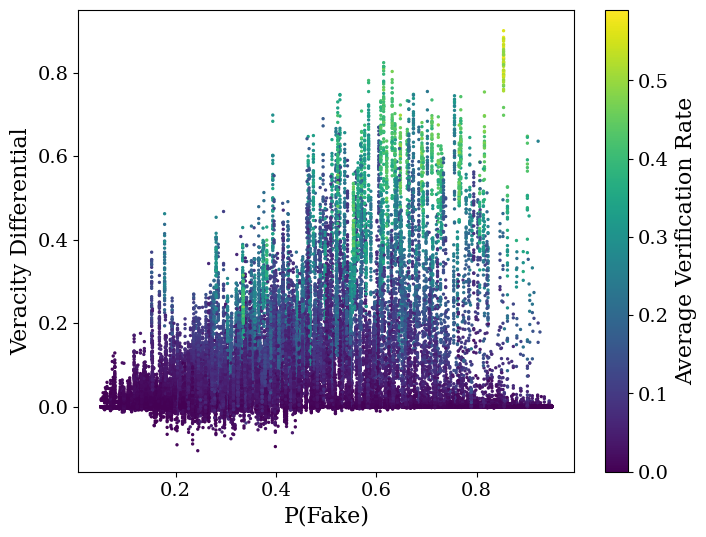

In [28]:
plt.scatter(
    sim_df["p_fake"],
    sim_df["veracity_differential"],
    c=sim_df["avg_verify_rate"],
    s=2
)
plt.colorbar(label="Average Verification Rate")
plt.xlabel("P(Fake)")
plt.ylabel("Veracity Differential")
plt.show()

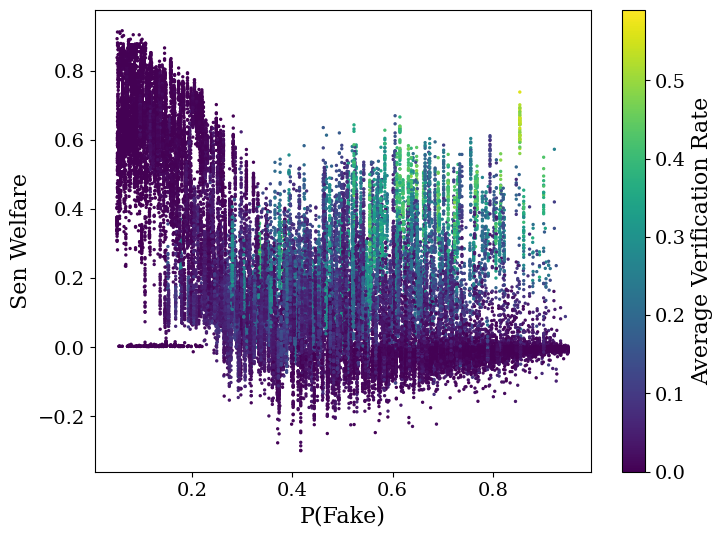

In [29]:
plt.scatter(
    sim_df["p_fake"],
    sim_df["sen_welfare"],
    s=2,
    c=sim_df["avg_verify_rate"]
)
plt.colorbar(label="Average Verification Rate")
plt.xlabel("P(Fake)")
plt.ylabel("Sen Welfare")
plt.show()

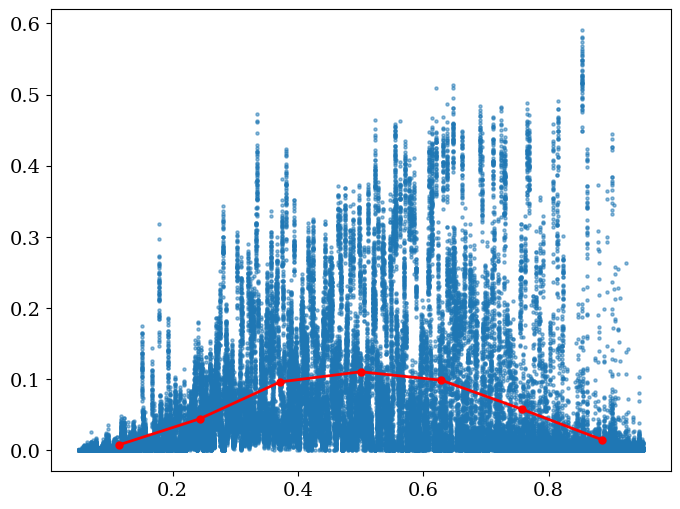

In [30]:
plt.scatter(
    sim_df["p_fake"],
    sim_df["avg_verify_rate"],
    alpha=0.5,
    s=5
)

# Bin p_fake into ~10 bins and compute mean avg_verify_rate per bin
sim_df["p_fake_bin"] = pd.cut(sim_df["p_fake"], bins=7)
bin_means = sim_df.groupby("p_fake_bin", observed=True)["avg_verify_rate"].mean()
bin_centers = bin_means.index.map(lambda x: x.mid)

plt.plot(bin_centers, bin_means.values, color="red", linewidth=2, marker="o", markersize=5, label="Bin mean")
plt.show()

### Radar Plots

In [31]:
vars_ = ["tpr", "fpr", "v_cost", "loss", "p_fake", "veracity_differential"]

scaler = MinMaxScaler()
sim_df_scaled = sim_df.copy()
sim_df_scaled[vars_] = scaler.fit_transform(sim_df[vars_])

n_regimes = 4

sim_df_scaled["welfare_regime"] = pd.qcut(
    sim_df_scaled["sen_welfare"], 
    q=n_regimes, 
    labels=list(range(n_regimes))
)

grouped_scaled = sim_df_scaled.groupby("welfare_regime")[vars_].mean()

In [32]:
def radar_plot(ax, values, labels, title):
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    values = values.tolist()
    
    # close the loop
    values += values[:1]
    angles += angles[:1]

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    ax.set_yticks([])
    # ax.set_title(title, fontsize=14, pad=20)

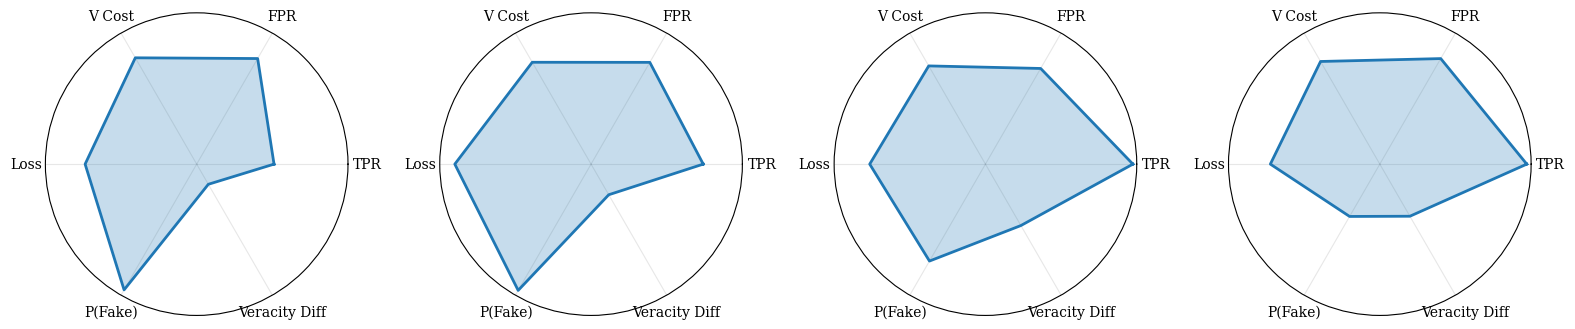

In [33]:
fig, axes = plt.subplots(1, n_regimes, figsize=(16, 5), subplot_kw=dict(polar=True))

labels = ["TPR", "FPR", "V Cost", "Loss", "P(Fake)", "Veracity Diff"]

for ax, regime in zip(axes, grouped_scaled.index):
    radar_plot(
        ax,
        grouped_scaled.loc[regime],
        labels,
        title=f"Welfare Regime #{regime}"
    )

plt.tight_layout()
plt.show()

### Network Visualization

In [34]:
# Attributes you can colour nodes by
COLOUR_OPTIONS = {
    "tpr_mean": "TPR Belief",
    "fpr_mean": "FPR Belief",
    "true_mean": "True Prevalence Belief",
    "agent_veracity": "Normalised Payoff",
    "true_shares": "# True Shares",
    "fake_shares": "# Fake Shares",
}

def beta_mean(alpha: pd.Series, beta: pd.Series) -> pd.Series:
    return alpha / (alpha + beta)

def build_node_attributes(nodes_df: pd.DataFrame) -> pd.DataFrame:
    """Derive belief-mean columns from raw alpha/beta columns."""
    df = nodes_df.copy()
    df["tpr_mean"]   = beta_mean(df["tpr_alpha"],  df["tpr_beta"])
    df["fpr_mean"]   = beta_mean(df["fpr_alpha"],  df["fpr_beta"])
    df["true_mean"]  = beta_mean(df["true_alpha"], df["true_beta"])
    return df

def find_sim(
    df: pd.DataFrame,
    v_cost: float | None = None,
    loss: float | None = None,
    tpr: float | None = None,
    fpr: float | None = None,
    p_fake: float | None = None,
    n: int = 1,
) -> pd.DataFrame:
    """
    Find the closest simulation(s) to a target parameter vector.
    Any parameter left as None is ignored in the distance calculation.

    Returns the top-n closest rows, sorted by ascending distance.
    """
    param_cols = {"v_cost": v_cost, "loss": loss, "tpr": tpr, "fpr": fpr, "p_fake": p_fake}
    targets = {col: val for col, val in param_cols.items() if val is not None}

    if not targets:
        raise ValueError("Provide at least one parameter to search by.")

    # Normalise each column to [0,1] using its observed range before computing distance
    dist = pd.Series(0.0, index=df.index)
    for col, target in targets.items():
        col_range = df[col].max() - df[col].min()
        scale = col_range if col_range > 0 else 1.0
        dist += ((df[col] - target) / scale) ** 2

    dist = np.sqrt(dist)
    top = df.assign(distance=dist).nsmallest(n, "distance")
    return top[["global_sim_id", "v_cost", "loss", "tpr", "fpr", "p_fake"]].reset_index(drop=True)

def plot_network(
    sim_dir: str | Path,
    global_sim_id: int,
    colour_by: str = "true_mean",
    cmap: str = "RdYlGn",
    node_size: int = 60,
    edge_alpha: float = 0.15,
    figsize: tuple = (12, 10),
    seed: int = 0,
    title: str | None = None,
    ax: plt.Axes | None = None,
) -> plt.Figure:
    """
    Parameters
    ----------
    sim_dir       : folder produced by run_lhs_sweep() (contains *.arrow files)
    global_sim_id : the simulation to visualise (1-based, matches the Arrow data)
    colour_by     : one of the keys in COLOUR_OPTIONS, or any column in the
                    node DataFrame
    cmap          : any matplotlib colormap name
    node_size     : marker size
    edge_alpha    : transparency of edges (keep low for dense graphs)
    seed          : spring-layout random seed for reproducibility
    """
    sim_dir = Path(sim_dir)

    nodes = node_df[node_df["global_sim_id"] == global_sim_id].copy().set_index("node_id")
    nodes = build_node_attributes(nodes)
    edges = edge_df[edge_df["global_sim_id"] == global_sim_id].copy()

    # ── build graph ───────────────────────────────────────────────────────────
    G = nx.DiGraph()
    G.add_nodes_from(nodes.index)
    for _, row in edges.iterrows():
        G.add_edge(int(row["src"]), int(row["dst"]))

    # ── layout ────────────────────────────────────────────────────────────────
    pos = nx.spring_layout(G, seed=seed, k=1.2 / np.sqrt(len(G)))

    # ── colour mapping ────────────────────────────────────────────────────────
    if colour_by not in nodes.columns:
        raise ValueError(
            f"'{colour_by}' not found.\n"
            f"Available: {list(nodes.columns)}"
        )
    values = nodes.loc[sorted(G.nodes()), colour_by].values
    norm   = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
    node_colours = [mapper.to_rgba(v) for v in values]

    # ── draw ──────────────────────────────────────────────────────────────────
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        alpha=edge_alpha, arrows=False,
        edge_color="grey", width=0.5
    )
    # nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colours,
        node_size=node_size,
        linewidths=0.3,
        edgecolors="white"
    )

    # colourbar
    mapper.set_array(values)
    cbar = fig.colorbar(mapper, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(COLOUR_OPTIONS.get(colour_by, colour_by), fontsize=10)
    ax.axis("off")

    if standalone:
        plt.tight_layout()
    return fig

def plot_network_grid(
    global_sim_id: int,
    cmap: str = "RdYlGn",
    node_size: int = 60,
    edge_alpha: float = 0.15,
    seed: int = 0,
    figsize_per_panel: tuple = (6, 5),
):
    """
    Plot the same network coloured by multiple attributes side-by-side.

    Parameters
    ----------
    attributes : list of colour_by keys; defaults to the four belief means
                 plus normalised payoff
    """
    attributes = list(COLOUR_OPTIONS.keys())

    ncols = min(3, len(attributes))
    nrows = int(np.ceil(len(attributes) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows)
    )
    axes = np.array(axes).flatten()

    nodes = node_df[node_df["global_sim_id"] == global_sim_id].copy().set_index("node_id")
    nodes = build_node_attributes(nodes)
    edges = edge_df[edge_df["global_sim_id"] == global_sim_id].copy()

    G = nx.DiGraph()
    G.add_nodes_from(nodes.index)
    for _, row in edges.iterrows():
        G.add_edge(int(row["src"]), int(row["dst"]))
    pos = nx.spring_layout(G, seed=seed, k=1.2 / np.sqrt(len(G)))

    for i, attr in enumerate(attributes):
        values = nodes.loc[sorted(G.nodes()), attr].values
        norm   = mcolors.Normalize(vmin=values.min(), vmax=values.max())
        mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
        colours = [mapper.to_rgba(v) for v in values]

        nx.draw_networkx_edges(G, pos, ax=axes[i], alpha=edge_alpha,
                               arrows=False, edge_color="grey", width=0.4)
        nx.draw_networkx_nodes(G, pos, ax=axes[i], node_color=colours,
                               node_size=node_size, linewidths=0.3,
                               edgecolors="white")
        mapper.set_array(values)
        cbar = fig.colorbar(mapper, ax=axes[i], fraction=0.035, pad=0.02)
        cbar.set_label(COLOUR_OPTIONS.get(attr, attr), fontsize=14)
        axes[i].axis("off")

    for j in range(len(attributes), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [35]:
find_sim(sim_df, v_cost=0.01, loss=3, tpr=0.85, fpr=0.10, p_fake=0.2)

,global_sim_id,v_cost,loss,tpr,fpr,p_fake
0,38701,0.120108,2.914287,0.890713,0.075204,0.16746


In [36]:
sim_dir = "data/" + sweep_string
sim_id = 1
colour = "true_mean"

print(sim_df[sim_df["global_sim_id"]==sim_id][["v_cost", "loss", "tpr", "fpr", "p_fake"]])

     v_cost      loss       tpr       fpr    p_fake
0  0.633085  1.344609  0.750503  0.389724  0.177964


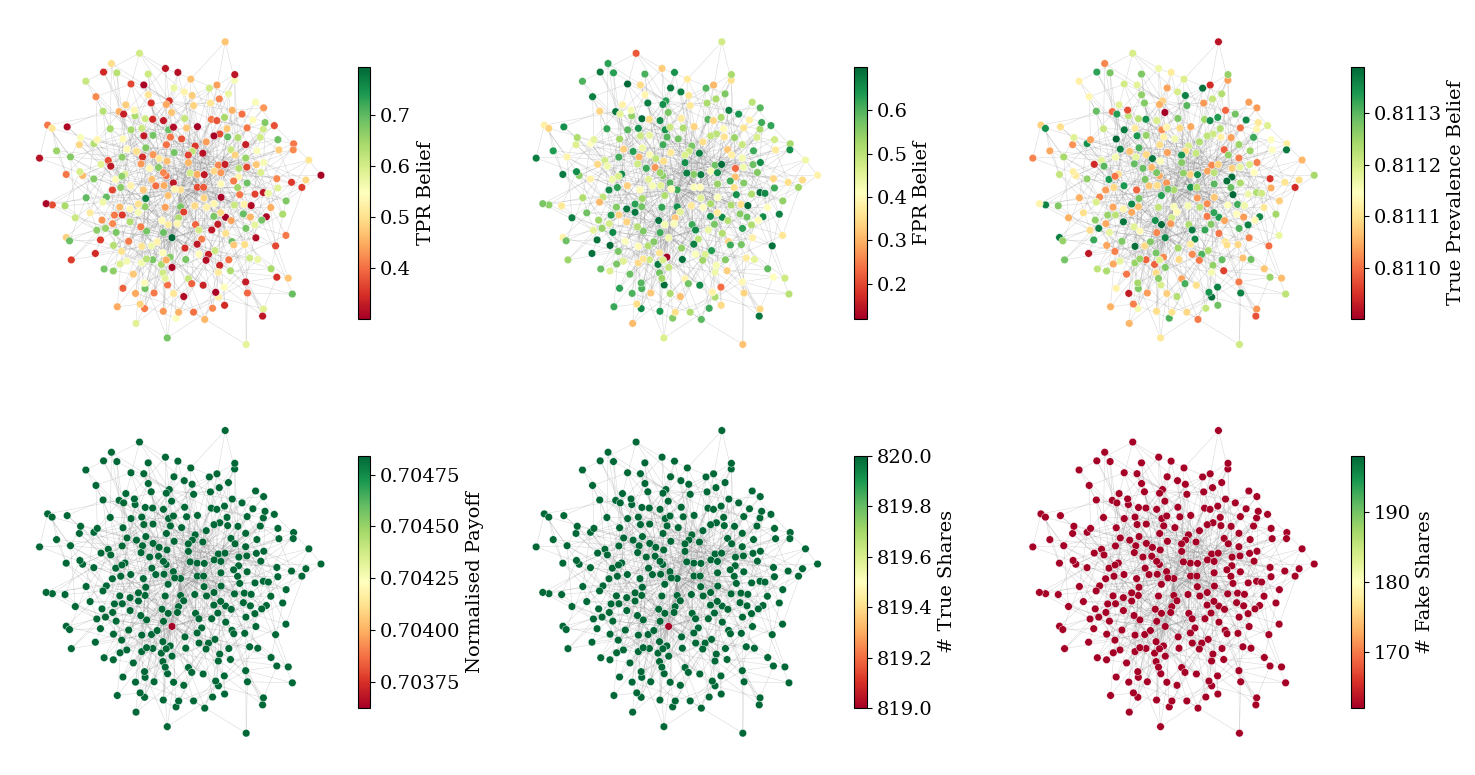

In [37]:
plot_network_grid(sim_id, cmap="RdYlGn", node_size=30, edge_alpha=0.15, seed=0, figsize_per_panel=(5, 4))